In [1]:
import pandas as pd
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import MultipleLocator
import networkx as nx
from scipy.stats import zscore
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import fdrcorrection
import math
from scipy.stats import pointbiserialr
from matplotlib.colors import LinearSegmentedColormap

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Helvetica', 'sans-serif']
plt.rcParams['svg.fonttype'] = 'none'

### Load data

In [ ]:
gnpc_hc = pd.read_csv('./data/GNPC_HC_clinical.csv')

In [10]:
pl_meta_sex_idx = pd.read_csv("./results/gnpc_meta_sex_idx_update.csv")
cell_type_performance = pd.read_csv("./results/Rev_UPDATE_cell_type_performance_gnpc_update_0912.csv")
df_age_gap = pd.read_csv("./results/Rev_UPDATE_gnpc_cell_type_gaps_z_v3.3_by_COHORT_HC_across_cohorts_z.csv")

In [11]:
pl_meta_sex_idx['hc'] = pl_meta_sex_idx['sample_id'].isin(gnpc_hc['sample_id']).astype(int)

Identify corresponding cohorts for each disease

In [15]:
df = pl_meta_sex_idx
min_samples = 10
suitable_cohorts = {}
all_cohorts = {}

for diagnosis in ['ad', 'pd', 'als', 'ftd', 'mci_sci']:
    
    suitable_cohorts[diagnosis] = [] 
    all_cohorts[diagnosis] = [] 
    cohorts = df['contributor_code'].unique()
    
    for cohort in cohorts:
        cohort_df = df[df['contributor_code'] == cohort]
        
        disease_count = sum(cohort_df[diagnosis] == 1)
        hc_count = sum(cohort_df['hc'] == 1)
        
        if disease_count >= min_samples and hc_count >= min_samples:
            suitable_cohorts[diagnosis].append(cohort)
            
        if disease_count > 0:
            all_cohorts[diagnosis].append(cohort)

suitable_cohorts

{'ad': ['A', 'C', 'D', 'F', 'G', 'I', 'J', 'L', 'Q', 'R'],
 'pd': ['C', 'F', 'J', 'L', 'Q', 'R'],
 'als': ['M'],
 'ftd': ['C', 'F', 'I', 'N', 'Q'],
 'mci_sci': ['A', 'B', 'C', 'D', 'G', 'I', 'J', 'N', 'P', 'Q', 'R']}

In [17]:
# load cell_type.csv
cell_type_df = pd.read_csv('./../../update/cell_type.csv')
cell_type_df = cell_type_df.replace(r'\\$', '', regex=True)
for column in cell_type_df.columns:
    #cell_type_df[column] = cell_type_df[column].astype(str).str.replace(' ', '.')  # Replace spaces with periods
    cell_type_df[column] = cell_type_df[column].astype(str).str.replace('-', ' ')  # Replace hyphens with periods
cell_type_df = cell_type_df.replace("Alveolar cells type", "Alveolar cells type 1")
cell_type_df.head()

columns = cell_type_df.columns

categories = {}
for index, row in cell_type_df.iterrows():
    cell = row[columns[0]]
    category = row[columns[1]]
    
    if category not in categories:
        categories[category] = []
    
    categories[category].append(cell)

In [21]:
age_gap_df = df_age_gap.iloc[:, 2:]
age_gap_df.head()

,Adipocytes,Alveolar cells type 1,Alveolar cells type 2,Astrocytes,B cells,Basal keratinocytes,Basal prostatic cells,Basal respiratory cells,Basal squamous epithelial cells,Bipolar cells,...,Smooth muscle cells,Spermatocytes,Spermatogonia,Squamous epithelial cells,Suprabasal keratinocytes,Syncytiotrophoblasts,T cells,dendritic cells,granulocytes,monocytes
0,-0.159425,-1.710388,0.100332,-0.161194,1.166856,-0.849447,0.424269,1.042000,0.072292,-0.180854,...,0.345272,0.849912,0.571341,-0.789126,-0.594454,1.373520,-0.269353,1.755543,-0.334738,0.249148
1,0.759192,-0.073912,0.761840,0.514613,-0.668403,-0.508687,0.421649,0.006805,-0.618540,-0.019252,...,2.446099,0.284774,0.372105,-0.838895,-0.588049,1.065297,0.091182,0.472148,0.434692,0.246752
2,1.833792,0.314897,1.597285,-0.799942,-0.277941,-1.084938,-0.525198,-0.056882,-0.405359,1.266716,...,-0.218070,-0.622350,-0.428783,0.529280,-0.101160,-0.504039,-0.874203,0.605767,-1.071982,-0.362439
3,1.133602,0.421317,0.534344,-0.584994,0.176620,0.288117,-0.747503,-0.302407,0.396059,1.115745,...,1.009395,-0.937007,0.488987,-0.295993,0.706337,-0.354463,-0.407602,-0.292575,0.848579,0.900432
4,0.255568,0.184588,-0.895706,-0.759750,-1.585075,1.344579,-0.911680,-1.222185,-4.204385,-0.150574,...,0.227038,-0.803658,-1.087423,-0.399969,-1.198503,-0.449724,-0.503307,-3.135970,-1.978870,-0.894968


In [22]:
drop_1=["Spermatogonia", "Late spermatids", 
          "Early spermatids",  "Spermatocytes", 
          "Oocytes", "Syncytiotrophoblasts", 
          "Extravillous trophoblasts", 
          "Cytotrophoblasts", #performance low
          "Peritubular cells",
          "Sertoli cells",
          "Prostatic glandular cells"]

drop_2 = ["Breast myoepithelial cells",
            "Ductal cells", "Ovarian stromal cells", "Leydig cells", "Basal squamous epithelial cells",
            "Salivary duct cells", "Basal keratinocytes", "Collecting duct cells",
            "Endometrial stromal cells", "Basal prostatic cells", "Granulosa cells", "Cytotrophoblasts",
            "Secretory cells", "Rod photoreceptor cells", "Glandular and luminal cells",
            "Squamous epithelial cells", "Cone photoreceptor cells", "Distal enterocytes",
            "Club cells", "Paneth cells", "Ionocytes", "Cholangiocytes", "Melanocytes"]

In [23]:
low_performing_cells = cell_type_performance[cell_type_performance['evaluation_gnpc'] < 0.15]
low_performing_cell_types = low_performing_cells['cell_type'].tolist()
low_performing_cell_types = [cell_type.replace(" ", ".") for cell_type in low_performing_cells['cell_type'].tolist()]
print("Cell types with evaluation_gnpc < 0.15:", low_performing_cell_types)

Cell types with evaluation_gnpc < 0.15: ['Basal.keratinocytes', 'Basal.prostatic.cells', 'Basal.squamous.epithelial.cells', 'Bipolar.cells', 'Breast.myoepithelial.cells', 'Collecting.duct.cells', 'Distal.enterocytes', 'Ductal.cells', 'Endometrial.stromal.cells', 'Granulosa.cells', 'Ionocytes', 'Leydig.cells', 'Melanocytes', 'Ovarian.stromal.cells', 'Secretory.cells', 'Squamous.epithelial.cells']


In [24]:
threshold_marker = 4
n_marker_below_threshold_cells = cell_type_performance[cell_type_performance['n_marker'] < threshold_marker]
n_marker_below_threshold_cells_types = n_marker_below_threshold_cells['cell_type'].tolist()
n_marker_below_threshold_cells_types = [cell_type.replace(" ", ".") for cell_type in n_marker_below_threshold_cells['cell_type'].tolist()]
n_marker_below_threshold_cells_types

['Basal.keratinocytes',
 'Basal.squamous.epithelial.cells',
 'Breast.myoepithelial.cells',
 'Cholangiocytes',
 'Club.cells',
 'Collecting.duct.cells',
 'Cytotrophoblasts',
 'Ductal.cells',
 'Leydig.cells',
 'Ovarian.stromal.cells',
 'Salivary.duct.cells',
 'Squamous.epithelial.cells']

In [25]:
import re
low_performing_cell_types = [re.sub(r"\.", " ", cell_type) for cell_type in low_performing_cell_types]
unique_low_performers = [cell_type for cell_type in low_performing_cell_types 
                        if cell_type not in drop_1 and cell_type not in drop_2]
unique_low_performers

['Bipolar cells']

In [26]:
n_marker_below_threshold_cells_types = [re.sub(r"\.", " ", cell_type) for cell_type in n_marker_below_threshold_cells_types]
unique_low_marker_cells = [cell_type for cell_type in n_marker_below_threshold_cells_types 
                        if cell_type not in drop_1 and cell_type not in drop_2 and cell_type not in unique_low_performers]
unique_low_marker_cells

[]

In [27]:
columns_to_drop = drop_1 + drop_2 + unique_low_performers + unique_low_marker_cells
filtered_age_gap_df = age_gap_df.drop(columns=columns_to_drop)
filtered_age_gap_df.shape

(14281, 43)

### Point-biserialr correlation analysis: neurodegeneration vs healthy

In [ ]:
from statsmodels.stats.multitest import multipletests

outcomes = ['ad', 'als', 'pd', 'ftd', 'mci_sci']
results_dict = {}

all_cell_types = []
all_outcomes = []
all_p_values = []
all_correlations = []

for outcome in outcomes:
    cell_types = []
    correlation_coefficients = []
    p_values = []
    
    # Use suitable cohorts for each outcome
    contributor_with_outcome = suitable_cohorts[outcome]
    
    # Filter data to include only outcome=1 and hc=1 samples from the selected cohorts
    outcome_samples = pl_meta_sex_idx[(pl_meta_sex_idx['contributor_code'].isin(contributor_with_outcome)) & 
                                     (pl_meta_sex_idx[outcome] == 1)]
    
    hc_samples = pl_meta_sex_idx[(pl_meta_sex_idx['contributor_code'].isin(contributor_with_outcome)) & 
                                (pl_meta_sex_idx['hc'] == 1)]
    
    # Combine outcome and hc samples
    combined_samples = pd.concat([outcome_samples, hc_samples])
    combined_indices = combined_samples.index
    
    # Create binary outcome status (1 for disease, 0 for hc)
    outcome_status = pd.Series(0, index=combined_indices)  # Start with all zeros (HC)
    outcome_status.loc[outcome_samples.index] = 1  # Set outcome samples to 1
    
    # Get age gaps for these samples
    filtered_age_gap_combined = filtered_age_gap_df.loc[combined_indices]
    
    print(f"Analysis for {outcome}:")
    print(f"Contributors: {contributor_with_outcome}")
    print(f"Disease samples: {len(outcome_samples)}")
    print(f"HC samples: {len(hc_samples)}")
    print(f"Total samples: {len(filtered_age_gap_combined)}")
    
    # Calculate correlation for each cell type
    for column in filtered_age_gap_df.columns:
        # Create temporary dataframe
        temp_df = pd.DataFrame({
            'age_gap': filtered_age_gap_combined[column],
            'outcome': outcome_status
        })
        
        # Drop any rows with missing values
        temp_df = temp_df.dropna()
        
        correlation, p_value = pointbiserialr(temp_df['age_gap'], temp_df['outcome'])

        cell_types.append(column)
        correlation_coefficients.append(correlation)
        p_values.append(p_value)

        all_cell_types.append(column)
        all_outcomes.append(outcome)
        all_p_values.append(p_value)
        all_correlations.append(correlation)
    
    if p_values:  # Check if we have any p-values
        rejected, p_values_adj = fdrcorrection(p_values)
        
        results_df = pd.DataFrame({
            'Cell_Type': cell_types,
            'Correlation': correlation_coefficients,
            'P_Value': p_values,
            'P_Value_Adjusted': p_values_adj,
            'Significant': rejected,
        })
        
        # Sort by absolute correlation value
        results_df = results_df.sort_values('Correlation', key=abs, ascending=False)
        
        results_dict[outcome] = results_df
    else:
        print(f"No valid results for {outcome}")

# Create combined results dataframe and perform overall FDR correction
if all_p_values:  # Check if we have any p-values
    all_results_df = pd.DataFrame({
        'Outcome': all_outcomes,
        'Cell_Type': all_cell_types,
        'Correlation': all_correlations,
        'P_Value': all_p_values
    })
    
    rejected_all, p_values_adj_all = fdrcorrection(all_results_df['P_Value'], alpha=0.05)
    all_results_df['P_Value_Adjusted_All'] = p_values_adj_all
    all_results_df['Significant_All'] = rejected_all
    
    rejected_tsbh, p_values_tsbh, _, _ = multipletests(all_results_df['P_Value'], alpha=0.05, method='fdr_tsbh')
    all_results_df['P_Value_TSBH_All'] = p_values_tsbh
    all_results_df['Significant_TSBH_All'] = rejected_tsbh

    # Add Bonferroni correction
    rejected_bonf, p_values_bonf, _, _ = multipletests(all_results_df['P_Value'], alpha=0.05, method='bonferroni')
    all_results_df['P_Value_Bonferroni_All'] = p_values_bonf
    all_results_df['Significant_Bonferroni_All'] = rejected_bonf
    
    # Add global adjusted p-values to individual outcome results
    for outcome in outcomes:
        if outcome in results_dict:
            # For each cell type in this outcome's results
            for cell_type in results_dict[outcome]['Cell_Type']:
                # Find the corresponding row in the all_results_df
                mask = (all_results_df['Outcome'] == outcome) & (all_results_df['Cell_Type'] == cell_type)
                if mask.any():
                    global_adj_p = all_results_df.loc[mask, 'P_Value_Adjusted_All'].values[0]
                    global_significant = all_results_df.loc[mask, 'Significant_All'].values[0]
                    global_tsbh = all_results_df.loc[mask, 'P_Value_TSBH_All'].values[0]
                    global_sig_tsbh = all_results_df.loc[mask, 'Significant_TSBH_All'].values[0]
                    global_bonf = all_results_df.loc[mask, 'P_Value_Bonferroni_All'].values[0]
                    global_sig_bonf = all_results_df.loc[mask, 'Significant_Bonferroni_All'].values[0]

                    # Add to the outcome-specific results dataframe
                    mask_outcome = results_dict[outcome]['Cell_Type'] == cell_type
                    results_dict[outcome].loc[mask_outcome, 'P_Value_Adjusted_All'] = global_adj_p
                    results_dict[outcome].loc[mask_outcome, 'Significant_All'] = global_significant
                    results_dict[outcome].loc[mask_outcome, 'P_Value_TSBH_All'] = global_tsbh
                    results_dict[outcome].loc[mask_outcome, 'Significant_TSBH_All'] = global_sig_tsbh
                    results_dict[outcome].loc[mask_outcome, 'P_Value_Bonferroni_All'] = global_bonf
                    results_dict[outcome].loc[mask_outcome, 'Significant_Bonferroni_All'] = global_sig_bonf

# Store individual outcome results for convenience
ad_results = results_dict.get('ad', pd.DataFrame())
als_results = results_dict.get('als', pd.DataFrame())
pd_results = results_dict.get('pd', pd.DataFrame())
ftd_results = results_dict.get('ftd', pd.DataFrame())
mci_sci_results = results_dict.get('mci_sci', pd.DataFrame())

Analysis for ad:
Contributors: ['A', 'C', 'D', 'F', 'G', 'I', 'J', 'L', 'Q', 'R']
Disease samples: 2761
HC samples: 5750
Total samples: 8511
Analysis for als:
Contributors: ['M']
Disease samples: 245
HC samples: 110
Total samples: 355
Analysis for pd:
Contributors: ['C', 'F', 'J', 'L', 'Q', 'R']
Disease samples: 476
HC samples: 3831
Total samples: 4307
Analysis for ftd:
Contributors: ['C', 'F', 'I', 'N', 'Q']
Disease samples: 199
HC samples: 3449
Total samples: 3648
Analysis for mci_sci:
Contributors: ['A', 'B', 'C', 'D', 'G', 'I', 'J', 'N', 'P', 'Q', 'R']
Disease samples: 1992
HC samples: 4688
Total samples: 6680


/tmp/ipykernel_91/3453019451.py:124: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results_dict[outcome].loc[mask_outcome, 'Significant_All'] = global_significant
/tmp/ipykernel_91/3453019451.py:126: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results_dict[outcome].loc[mask_outcome, 'Significant_TSBH_All'] = global_sig_tsbh
/tmp/ipykernel_91/3453019451.py:128: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results_dict[outcome].loc[mask_outcome, 'Significant_Bonferroni_All'] = global_sig

In [25]:
case_counts = []
for outcome in ['ad', 'als', 'pd', 'ftd', 'mci_sci']:
    contributor_with_outcome = suitable_cohorts[outcome]
    disease_count = len(pl_meta_sex_idx[(pl_meta_sex_idx['contributor_code'].isin(contributor_with_outcome)) & 
                                         (pl_meta_sex_idx[outcome] == 1)])
    case_counts.append(disease_count)

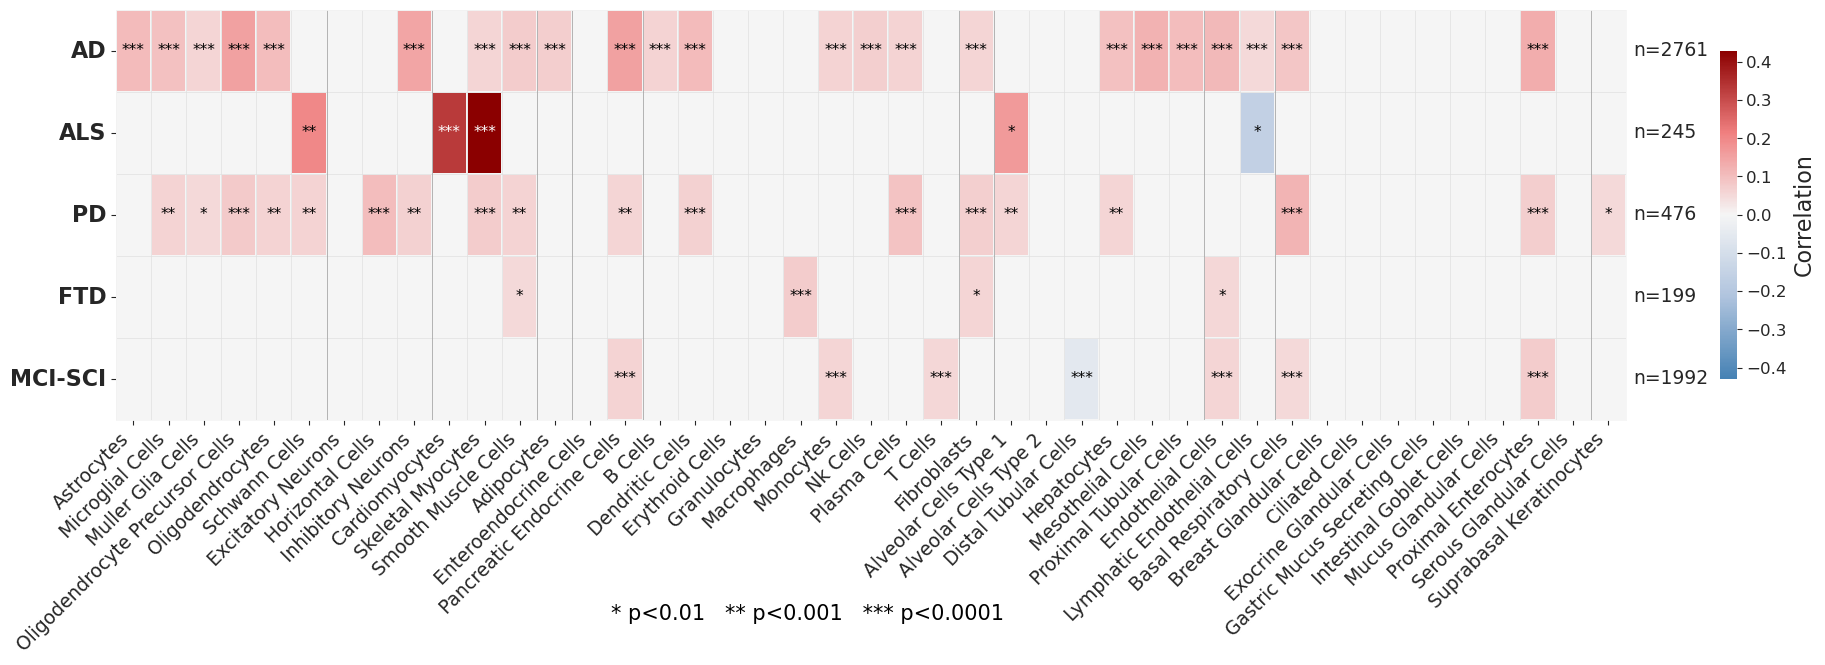

In [ ]:
# Get the list of all cell types across all datasets
all_cell_types = set()
for outcome_results in [ad_results, als_results, pd_results, ftd_results, mci_sci_results]:
    all_cell_types.update(outcome_results['Cell_Type'].tolist())

# Define the desired category order
category_order = ["Glial cells", 
                  "Neuronal cells",
                  "Muscle cells",
                  "Adipocytes", 
                   "Endocrine cells", 
                 "Blood & immune cells",
                 "Mesenchymal cells", 
                 "Specialized epithelial cells",
                  "Endothelial cells",
                 "Glandular epithelial cells", 
                 "Squamous epithelial cells"]

# Create an ordered list of cell types based on category_order
ordered_cell_types = []
for category in category_order:
    # Filter to only include cell types that are in our data
    category_cells = [cell for cell in categories[category] if cell in all_cell_types]
    ordered_cell_types.extend(category_cells)

# Create a DataFrame for the heatmap
outcomes = ['AD', 'ALS', 'PD', 'FTD', 'MCI-SCI']
heatmap_data = pd.DataFrame(index=outcomes, columns=ordered_cell_types)

# Create a DataFrame for significance mask (True where not significant)
significance_mask = pd.DataFrame(True, index=outcomes, columns=ordered_cell_types)

# Create a DataFrame for significance annotation
significance_annotation = pd.DataFrame('', index=outcomes, columns=ordered_cell_types)

# Fill the heatmap data, significance mask, and annotations
for i, outcome_results in enumerate([ad_results, als_results, pd_results, ftd_results, mci_sci_results]):
    outcome_name = outcomes[i]
    
    # Create dictionaries for correlation, significance, and p-values
    corr_dict = dict(zip(outcome_results['Cell_Type'], outcome_results['Correlation']))
    sig_dict = dict(zip(outcome_results['Cell_Type'], outcome_results['Significant_All']))
    pval_dict = dict(zip(outcome_results['Cell_Type'], outcome_results['P_Value_Adjusted_All']))
    
    # Fill in the data for this outcome
    for cell_type in ordered_cell_types:
        if cell_type in corr_dict:
            correlation_value = corr_dict[cell_type]
            p_value = pval_dict[cell_type]
            
            # Only show correlations with p-value < 0.01
            if p_value < 0.01 and abs(correlation_value) > 0.05:
                heatmap_data.loc[outcome_name, cell_type] = correlation_value
                significance_mask.loc[outcome_name, cell_type] = False  # Show this cell
                
                # Add significance annotation based on p-value
                if p_value < 0.0001:
                    significance_annotation.loc[outcome_name, cell_type] = '***'
                elif p_value < 0.001:
                    significance_annotation.loc[outcome_name, cell_type] = '**'
                elif p_value < 0.01:
                    significance_annotation.loc[outcome_name, cell_type] = '*'
            else:
                # Mask cells with p-value >= 0.01
                heatmap_data.loc[outcome_name, cell_type] = 0
                significance_mask.loc[outcome_name, cell_type] = True
        else:
            heatmap_data.loc[outcome_name, cell_type] = 0
            significance_mask.loc[outcome_name, cell_type] = True


# Replace NaN with 0
heatmap_data = heatmap_data.fillna(0)

# Get the maximum absolute correlation value for symmetric color scaling
max_corr = max(abs(heatmap_data.values.min()), abs(heatmap_data.values.max()))

colors_rb = [(0.0, 'steelblue'), 
             (0.25, 'lightsteelblue'),
             (0.5, 'whitesmoke'),
             (0.75, 'lightcoral'),
             (1.0, 'darkred')]
cmap_rb = LinearSegmentedColormap.from_list('custom_rb', colors_rb)

plt.figure(figsize=(21, 5))
plt.rcParams['figure.facecolor'] = 'white'

ax = sns.heatmap(
    heatmap_data,
    cmap=cmap_rb,
    vmin=-max_corr,
    vmax=max_corr,
    center=0,
    mask=significance_mask,
    cbar_kws={"label": "Correlation", "shrink": 0.8},
    linewidths=0.01,  
    linecolor='whitesmoke',
    square=False,
    annot=False
)

ax.set_facecolor('whitesmoke')  
for edge, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color('whitesmoke')
    spine.set_linewidth(0.6)

plt.pcolor(
    np.ones(heatmap_data.shape) * np.nan,
    cmap=plt.cm.colors.ListedColormap(['whitesmoke']),
    alpha=0.5
)

for i in range(len(outcomes) + 1):
    plt.axhline(i, color='#e0e0e0', linewidth=0.5)

for i in range(len(ordered_cell_types) + 1):
    plt.axvline(i, color='#e0e0e0', linewidth=0.5)

# Add significance annotations with improved placement
for i, outcome in enumerate(outcomes):
    for j, cell_type in enumerate(ordered_cell_types):
        if significance_annotation.loc[outcome, cell_type]:
            text = significance_annotation.loc[outcome, cell_type]
            text_color = 'white' if abs(heatmap_data.loc[outcome, cell_type]) > max_corr/2 else 'black'
            plt.text(j + 0.5, i + 0.5, text, 
                     horizontalalignment='center',
                     verticalalignment='center',
                     fontsize=11, color=text_color)

# Increase y-axis label font size 
plt.yticks(np.arange(len(outcomes)) + 0.5, outcomes, fontsize=16, rotation=360, fontweight='bold')

for i, (outcome, n) in enumerate(zip(outcomes, case_counts)):
    plt.text(len(ordered_cell_types) + 0.2, i + 0.5, f'n={n}', 
             fontsize=13.5, va='center', ha='left')

# Format cell type names by replacing dots with spaces
formatted_cell_types = [cell_type.replace('.', ' ').title() for cell_type in ordered_cell_types]

plt.subplots_adjust(bottom=0.5)

plt.xticks(np.arange(len(ordered_cell_types)) + 0.5, formatted_cell_types, 
           rotation=45, fontsize=13.5, ha='right')

cbar = ax.collections[0].colorbar
cbar_pos = cbar.ax.get_position()
cbar.ax.set_position([cbar_pos.x0 + 0.1, cbar_pos.y0, cbar_pos.width, cbar_pos.height])
cbar.ax.tick_params(labelsize=12) 
cbar.ax.set_ylabel("Correlation", fontsize=16)

# Add category dividers and labels
current_pos = 0
for category in category_order:  # Use category_order here
    if category in categories:  # Check if the category exists in the categories dictionary
        category_cells = [cell for cell in categories[category] if cell in all_cell_types]
        if category_cells:  # Only process if category has cells in our data
            category_width = len(category_cells)
            mid_point = current_pos + category_width/2
            
            # Add vertical lines to separate categories (subtle lines)
            if current_pos > 0:
                plt.axvline(x=current_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.7)
            
            current_pos += category_width

plt.tight_layout()

plt.subplots_adjust(bottom=0.15)

plt.figtext(0.3, -0.25, "* p<0.01   ** p<0.001   *** p<0.0001", 
            ha="left", 
            fontsize=15, color='black')

filename = './Rev_results/figure3_GNPC_disease_heatmap'
plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{filename}.svg", dpi=300, bbox_inches='tight', format='svg')
plt.savefig(f"{filename}.pdf", dpi=300, bbox_inches='tight', format='pdf')

plt.show()

### Confounding analysis: AD vs pancreatic cell aging

Sample sizes:
HC without T2D: n=3959
HC with T2D: n=311
AD without T2D: n=2234
AD with T2D: n=185


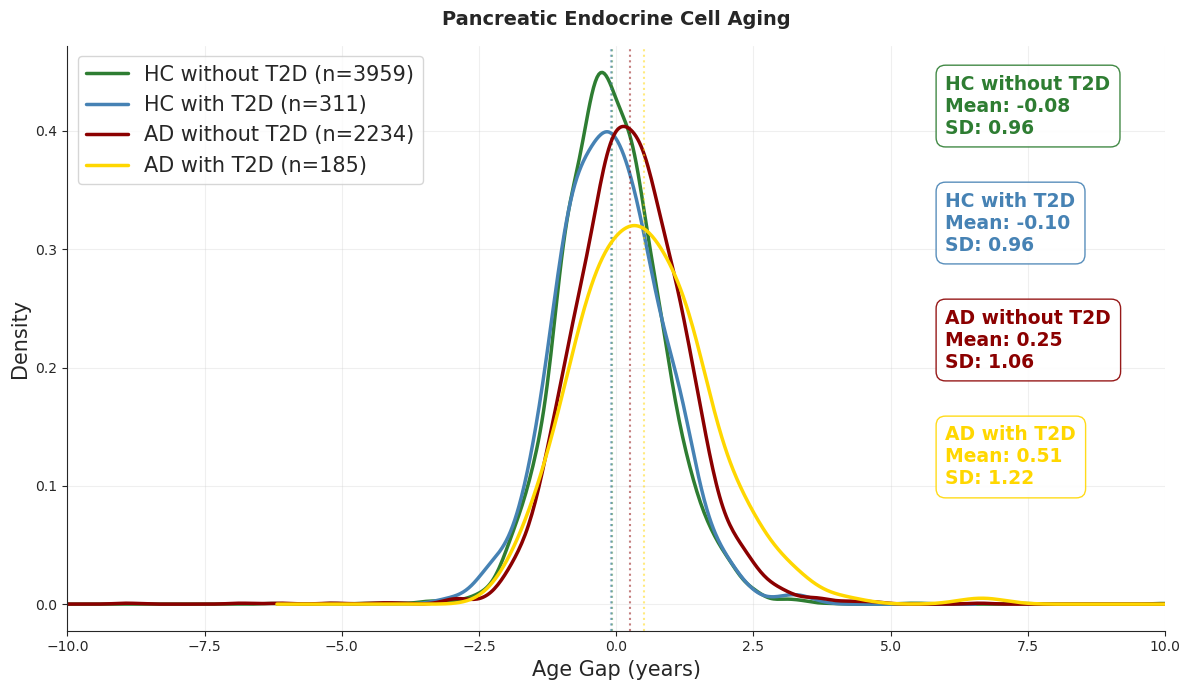


Detailed Statistics:

HC without T2D (n=3959):
  Mean ± SD: -0.08 ± 0.96 years
  Median [IQR]: -0.13 [-0.71 - 0.48]
  Range: [-6.26 - 9.95]

HC with T2D (n=311):
  Mean ± SD: -0.10 ± 0.96 years
  Median [IQR]: -0.14 [-0.76 - 0.50]
  Range: [-3.00 - 3.36]

AD without T2D (n=2234):
  Mean ± SD: 0.25 ± 1.06 years
  Median [IQR]: 0.22 [-0.40 - 0.91]
  Range: [-8.91 - 6.62]

AD with T2D (n=185):
  Mean ± SD: 0.51 ± 1.22 years
  Median [IQR]: 0.43 [-0.38 - 1.21]
  Range: [-1.90 - 6.66]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

outcome = 'ad'
cell_type = 'Pancreatic endocrine cells'  

# Get suitable cohorts for AD
contributor_with_outcome = suitable_cohorts[outcome]

# Filter samples from suitable cohorts
cohort_samples = pl_meta_sex_idx[pl_meta_sex_idx['contributor_code'].isin(contributor_with_outcome)]

# Create 4 groups based on AD and T2D status
hc_no_t2d = cohort_samples[(cohort_samples['hc'] == 1) & (cohort_samples['diabetes'] == 0)]
hc_with_t2d = cohort_samples[(cohort_samples['hc'] == 1) & (cohort_samples['diabetes'] == 1)]
ad_no_t2d = cohort_samples[(cohort_samples['ad'] == 1) & (cohort_samples['diabetes'] == 0)]
ad_with_t2d = cohort_samples[(cohort_samples['ad'] == 1) & (cohort_samples['diabetes'] == 1)]

# Get age gaps for each group
hc_no_t2d_ages = filtered_age_gap_df.loc[hc_no_t2d.index, cell_type].dropna()
hc_with_t2d_ages = filtered_age_gap_df.loc[hc_with_t2d.index, cell_type].dropna()
ad_no_t2d_ages = filtered_age_gap_df.loc[ad_no_t2d.index, cell_type].dropna()
ad_with_t2d_ages = filtered_age_gap_df.loc[ad_with_t2d.index, cell_type].dropna()

print("Sample sizes:")
print(f"HC without T2D: n={len(hc_no_t2d_ages)}")
print(f"HC with T2D: n={len(hc_with_t2d_ages)}")
print(f"AD without T2D: n={len(ad_no_t2d_ages)}")
print(f"AD with T2D: n={len(ad_with_t2d_ages)}")

fig = plt.figure(figsize=(15, 7))
ax = plt.subplot(1, 1, 1)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Define distinct colors for each group
colors = {
    'hc_no_t2d': '#2E7D32',    
    'hc_with_t2d': 'steelblue', 
    'ad_no_t2d': 'darkred',    
    'ad_with_t2d': 'gold'  
}

stats_text = []
y_positions = [0.85, 0.65, 0.45, 0.25]  # Vertical positions for stats

# Plot each group and calculate statistics
groups = [
    ('hc_no_t2d', hc_no_t2d_ages, 'HC without T2D'),
    ('hc_with_t2d', hc_with_t2d_ages, 'HC with T2D'),
    ('ad_no_t2d', ad_no_t2d_ages, 'AD without T2D'),
    ('ad_with_t2d', ad_with_t2d_ages, 'AD with T2D')
]

for i, (key, data, label) in enumerate(groups):
    if len(data) > 0:
        # Plot density
        data.plot(kind='density', ax=ax, label=f'{label} (n={len(data)})', 
                 color=colors[key], linewidth=2.5)
        
        # Calculate statistics
        mean_val = np.mean(data)
        median_val = np.median(data)
        std_val = np.std(data)
        
        # Add vertical line for mean
        ax.axvline(mean_val, color=colors[key], linestyle=':', alpha=0.5, linewidth=1.5)
        
        stats_str = f'{label}\n'
        stats_str += f'Mean: {mean_val:.2f}\n'
        stats_str += f'SD: {std_val:.2f}'
        
        # Add stats annotation to the right of the plot (moved left from 1.02 to 0.98)
        ax.text(0.8, y_positions[i], stats_str, 
                transform=ax.transAxes,
                fontsize=13.5,
                color=colors[key],
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', 
                         facecolor='white', 
                         edgecolor=colors[key],
                         linewidth=1,
                         alpha=0.9))

ax.set_xlim(-10, 10)
ax.set_xlabel('Age Gap (years)', fontsize=15)
ax.set_ylabel('Density', fontsize=15)
ax.set_title('Pancreatic Endocrine Cell Aging',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=15)
ax.grid(True, alpha=0.3)

# Adjust layout to make room for stats
plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()

print("\n" + "="*50)
print("Detailed Statistics:")
print("="*50)

for key, data, label in groups:
    if len(data) > 0:
        print(f"\n{label} (n={len(data)}):")
        print(f"  Mean ± SD: {np.mean(data):.2f} ± {np.std(data):.2f} years")
        print(f"  Median [IQR]: {np.median(data):.2f} [{np.percentile(data, 25):.2f} - {np.percentile(data, 75):.2f}]")
        print(f"  Range: [{np.min(data):.2f} - {np.max(data):.2f}]")

Sample sizes:
HC without T2D: n=3959
HC with T2D: n=311
AD without T2D: n=2234
AD with T2D: n=185


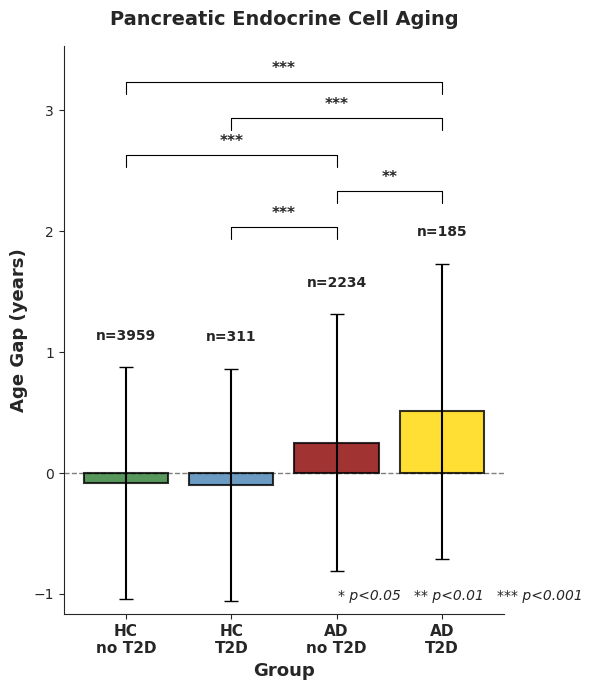


Statistical Comparisons (t-tests):
HC no T2D vs HC T2D: p = 0.7916
HC no T2D vs AD no T2D: p = 0.0000
   ***
HC no T2D vs AD T2D: p = 0.0000
   ***
HC T2D vs AD no T2D: p = 0.0000
   ***
HC T2D vs AD T2D: p = 0.0000
   ***
AD no T2D vs AD T2D: p = 0.0016
   **


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations

outcome = 'ad'
cell_type = 'Pancreatic endocrine cells' 

# Get suitable cohorts for AD
contributor_with_outcome = suitable_cohorts[outcome]

# Filter samples from suitable cohorts
cohort_samples = pl_meta_sex_idx[pl_meta_sex_idx['contributor_code'].isin(contributor_with_outcome)]

# Create 4 groups based on AD and T2D status
hc_no_t2d = cohort_samples[(cohort_samples['hc'] == 1) & (cohort_samples['diabetes'] == 0)]
hc_with_t2d = cohort_samples[(cohort_samples['hc'] == 1) & (cohort_samples['diabetes'] == 1)]
ad_no_t2d = cohort_samples[(cohort_samples['ad'] == 1) & (cohort_samples['diabetes'] == 0)]
ad_with_t2d = cohort_samples[(cohort_samples['ad'] == 1) & (cohort_samples['diabetes'] == 1)]

# Get age gaps for each group
hc_no_t2d_ages = filtered_age_gap_df.loc[hc_no_t2d.index, cell_type].dropna()
hc_with_t2d_ages = filtered_age_gap_df.loc[hc_with_t2d.index, cell_type].dropna()
ad_no_t2d_ages = filtered_age_gap_df.loc[ad_no_t2d.index, cell_type].dropna()
ad_with_t2d_ages = filtered_age_gap_df.loc[ad_with_t2d.index, cell_type].dropna()

print("Sample sizes:")
print(f"HC without T2D: n={len(hc_no_t2d_ages)}")
print(f"HC with T2D: n={len(hc_with_t2d_ages)}")
print(f"AD without T2D: n={len(ad_no_t2d_ages)}")
print(f"AD with T2D: n={len(ad_with_t2d_ages)}")

fig, ax = plt.subplots(figsize=(6, 7))

groups = [
    {'name': 'HC\nno T2D', 'data': hc_no_t2d_ages, 'color': '#2E7D32'},
    {'name': 'HC\nT2D', 'data': hc_with_t2d_ages, 'color': 'steelblue'},
    {'name': 'AD\nno T2D', 'data': ad_no_t2d_ages, 'color': 'darkred'},
    {'name': 'AD\nT2D', 'data': ad_with_t2d_ages, 'color': 'gold'}
]

plot_data = []
raw_data = {}
for i, group in enumerate(groups):
    if len(group['data']) > 0:
        mean_val = np.mean(group['data'])
        std_val = np.std(group['data'])
        
        plot_data.append({
            'name': group['name'],
            'mean': mean_val,
            'std': std_val,
            'n': len(group['data']),
            'color': group['color'],
            'idx': i
        })
        raw_data[i] = group['data']

x_pos = np.arange(len(plot_data))

bars = ax.bar(x_pos, 
              [d['mean'] for d in plot_data],
              yerr=[d['std'] for d in plot_data],
              capsize=5,
              color=[d['color'] for d in plot_data],
              alpha=0.8,
              edgecolor='black',
              linewidth=1.5,
              error_kw={'linewidth': 1.5})

for i, (bar, d) in enumerate(zip(bars, plot_data)):
    height = bar.get_height()
    y_pos = height + d['std'] + 0.2
    
    ax.text(bar.get_x() + bar.get_width()/2., y_pos,
            f'n={d["n"]}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Perform ALL pairwise comparisons
all_comparisons = list(combinations(range(len(plot_data)), 2))

# Find all significant comparisons
significant_comparisons = []
for idx1, idx2 in all_comparisons:
    if idx1 in raw_data and idx2 in raw_data:
        _, p_val = stats.ttest_ind(raw_data[idx1], raw_data[idx2])
        if p_val < 0.05:
            significant_comparisons.append({
                'idx1': idx1, 
                'idx2': idx2,
                'p_val': p_val,
                'distance': abs(idx2 - idx1)
            })

# Sort by distance between bars to minimize overlap
significant_comparisons.sort(key=lambda x: (x['distance'], x['idx1']))

# Get maximum height for positioning significance bars
max_height = max([d['mean'] + d['std'] for d in plot_data])

# Calculate spacing for significance bars
sig_height_start = max_height + 0.3
sig_increment = 0.3

# Assign heights to avoid overlap
comparison_heights = {}
used_heights = []

for comp in significant_comparisons:
    key = (comp['idx1'], comp['idx2'])
    
    # Find the minimum available height that doesn't overlap
    height = sig_height_start
    level = 0
    while True:
        overlap = False
        for existing in used_heights:
            if (existing['idx1'] <= comp['idx1'] <= existing['idx2'] or 
                existing['idx1'] <= comp['idx2'] <= existing['idx2'] or
                comp['idx1'] <= existing['idx1'] <= comp['idx2'] or
                comp['idx1'] <= existing['idx2'] <= comp['idx2']):
                if abs(existing['height'] - height) < sig_increment * 0.8:
                    overlap = True
                    break
        
        if not overlap:
            break
        
        level += 1
        height = sig_height_start + (sig_increment * level)
    
    comparison_heights[key] = height
    used_heights.append({
        'idx1': comp['idx1'], 
        'idx2': comp['idx2'], 
        'height': height
    })

for comp in significant_comparisons:
    idx1, idx2 = comp['idx1'], comp['idx2']
    p_val = comp['p_val']
    height = comparison_heights[(idx1, idx2)]
    
    if p_val < 0.001:
        sig_text = '***'
    elif p_val < 0.01:
        sig_text = '**'
    elif p_val < 0.05:
        sig_text = '*'
    
    # Draw bracket
    # Horizontal line
    ax.plot([idx1, idx2], [height, height], 
           'k-', linewidth=0.8)
    
    # Small vertical ticks at ends
    tick_height = 0.1
    ax.plot([idx1, idx1], [height, height - tick_height], 
           'k-', linewidth=0.8)
    ax.plot([idx2, idx2], [height, height - tick_height], 
           'k-', linewidth=0.8)
    
    # Add significance text
    ax.text((idx1 + idx2) / 2, height + 0.05, sig_text,
           ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([d['name'] for d in plot_data], fontsize=11, fontweight='bold')
ax.set_xlabel('Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Age Gap (years)', fontsize=13, fontweight='bold')
ax.set_title('Pancreatic Endocrine Cell Aging',
             fontsize=14, fontweight='bold', pad=15)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

all_values = [(d['mean'] - d['std'], d['mean'] + d['std']) for d in plot_data]
y_min = min([v[0] for v in all_values]) * 1.1

if used_heights:
    max_bracket_height = max([h['height'] for h in used_heights])
    y_max = max_bracket_height + 0.3
else:
    y_max = max([v[1] for v in all_values]) * 1.1

ax.set_ylim(y_min, y_max)

# Add legend for significance levels
legend_text = '* p<0.05   ** p<0.01   *** p<0.001'
ax.text(0.9, 0.02, legend_text,
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Statistical Comparisons (t-tests):")
print("="*50)

group_names = [d['name'].replace('\n', ' ') for d in plot_data]
for idx1, idx2 in all_comparisons:
    if idx1 in raw_data and idx2 in raw_data:
        _, p_val = stats.ttest_ind(raw_data[idx1], raw_data[idx2])
        print(f"{group_names[idx1]} vs {group_names[idx2]}: p = {p_val:.4f}")
        if p_val < 0.001:
            print("   ***")
        elif p_val < 0.01:
            print("   **")
        elif p_val < 0.05:
            print("   *")

### Bootstrapping analysis and additional false discovery rate correction

In [32]:
N_bootstrap = 1000

# Collect significant results from heatmap
significant_results = []

for outcome_results, outcome_name in zip([ad_results, als_results, pd_results, ftd_results, mci_sci_results], 
                                         ['AD', 'ALS', 'PD', 'FTD', 'MCI-SCI']):
    for _, row in outcome_results.iterrows():
        if row['P_Value_Adjusted_All'] < 0.01 and abs(row['Correlation']) > 0.05:
            significant_results.append({
                'outcome': outcome_name,
                'cell_type': row['Cell_Type'],
                'correlation': row['Correlation'],
                'p_bh': row['P_Value_Adjusted_All'],
                'p_tsbh': row['P_Value_TSBH_All'],
                'p_bonf': row['P_Value_Bonferroni_All']
            })

# Calculate bootstrap CIs
for result in significant_results:
    outcome_key = result['outcome'].lower().replace('-', '_')
    contributor_with_outcome = suitable_cohorts[outcome_key]
    
    outcome_samples = pl_meta_sex_idx[(pl_meta_sex_idx['contributor_code'].isin(contributor_with_outcome)) & 
                                     (pl_meta_sex_idx[outcome_key] == 1)]
    hc_samples = pl_meta_sex_idx[(pl_meta_sex_idx['contributor_code'].isin(contributor_with_outcome)) & 
                                (pl_meta_sex_idx['hc'] == 1)]
    
    combined_samples = pd.concat([outcome_samples, hc_samples])
    outcome_status = pd.Series(0, index=combined_samples.index)
    outcome_status.loc[outcome_samples.index] = 1
    
    age_gap_data = filtered_age_gap_df.loc[combined_samples.index, result['cell_type']]
    valid_idx = ~age_gap_data.isna()
    age_gap_clean = age_gap_data[valid_idx]
    outcome_clean = outcome_status[valid_idx]
    
    # Bootstrap
    correlations = []
    for _ in range(N_bootstrap):
        idx = np.random.choice(len(age_gap_clean), len(age_gap_clean), replace=True)
        corr, _ = pointbiserialr(age_gap_clean.iloc[idx], outcome_clean.iloc[idx])
        correlations.append(corr)
    
    result['ci_lower'] = np.percentile(correlations, 2.5)
    result['ci_upper'] = np.percentile(correlations, 97.5)

In [ ]:
# Filter for AD and ALS results
ad_significant = [r for r in significant_results if r['outcome'] == 'AD']
als_significant = [r for r in significant_results if r['outcome'] == 'ALS']

# Sort by absolute correlation value (descending)
ad_sorted = sorted(ad_significant, key=lambda x: abs(x['correlation']), reverse=True)
als_sorted = sorted(als_significant, key=lambda x: abs(x['correlation']), reverse=True)

# Print top 3 for AD
print("=" * 80)
print("TOP 3 SIGNIFICANT CORRELATIONS FOR AD")
print("=" * 80)
for i, result in enumerate(ad_sorted[:3], 1):
    print(f"\nRank {i}:")
    print(f"  Cell Type: {result['cell_type']}")
    print(f"  Correlation: {result['correlation']:.4f}")
    print(f"  95% CI: [{result['ci_lower']:.4f}, {result['ci_upper']:.4f}]")
    print(f"  P-value (BH adjusted): {result['p_bh']:.2e}")
    print(f"  P-value (TSBH): {result['p_tsbh']:.2e}")
    print(f"  P-value (Bonferroni): {result['p_bonf']:.2e}")

# Print top 3 for ALS
print("\n" + "=" * 80)
print("TOP 3 SIGNIFICANT CORRELATIONS FOR ALS")
print("=" * 80)
for i, result in enumerate(als_sorted[:3], 1):
    print(f"\nRank {i}:")
    print(f"  Cell Type: {result['cell_type']}")
    print(f"  Correlation: {result['correlation']:.4f}")
    print(f"  95% CI: [{result['ci_lower']:.4f}, {result['ci_upper']:.4f}]")
    print(f"  P-value (BH adjusted): {result['p_bh']:.2e}")
    print(f"  P-value (TSBH): {result['p_tsbh']:.2e}")
    print(f"  P-value (Bonferroni): {result['p_bonf']:.2e}")

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Total significant associations for AD: {len(ad_sorted)}")
print(f"Total significant associations for ALS: {len(als_sorted)}")

TOP 3 SIGNIFICANT CORRELATIONS FOR AD

Rank 1:
  Cell Type: Oligodendrocyte precursor cells
  Correlation: 0.1537
  95% CI: [0.1305, 0.1773]
  P-value (BH adjusted): 9.32e-44
  P-value (TSBH): 4.86e-44
  P-value (Bonferroni): 9.32e-44

Rank 2:
  Cell Type: Pancreatic endocrine cells
  Correlation: 0.1528
  95% CI: [0.1294, 0.1760]
  P-value (BH adjusted): 1.74e-43
  P-value (TSBH): 9.09e-44
  P-value (Bonferroni): 3.49e-43

Rank 3:
  Cell Type: Inhibitory neurons
  Correlation: 0.1460
  95% CI: [0.1241, 0.1674]
  P-value (BH adjusted): 7.42e-40
  P-value (TSBH): 3.87e-40
  P-value (Bonferroni): 2.23e-39

TOP 3 SIGNIFICANT CORRELATIONS FOR ALS

Rank 1:
  Cell Type: Skeletal myocytes
  Correlation: 0.4288
  95% CI: [0.3465, 0.5073]
  P-value (BH adjusted): 5.25e-16
  P-value (TSBH): 2.73e-16
  P-value (Bonferroni): 6.82e-15

Rank 2:
  Cell Type: Cardiomyocytes
  Correlation: 0.3306
  95% CI: [0.2455, 0.4138]
  P-value (BH adjusted): 2.04e-09
  P-value (TSBH): 1.06e-09
  P-value (Bonferro

In [37]:
for result in significant_results:
    if result['cell_type'] == "Horizontal cells":
        result['cell_type'] = "NEFL-C1QL2 Proj Neurons"

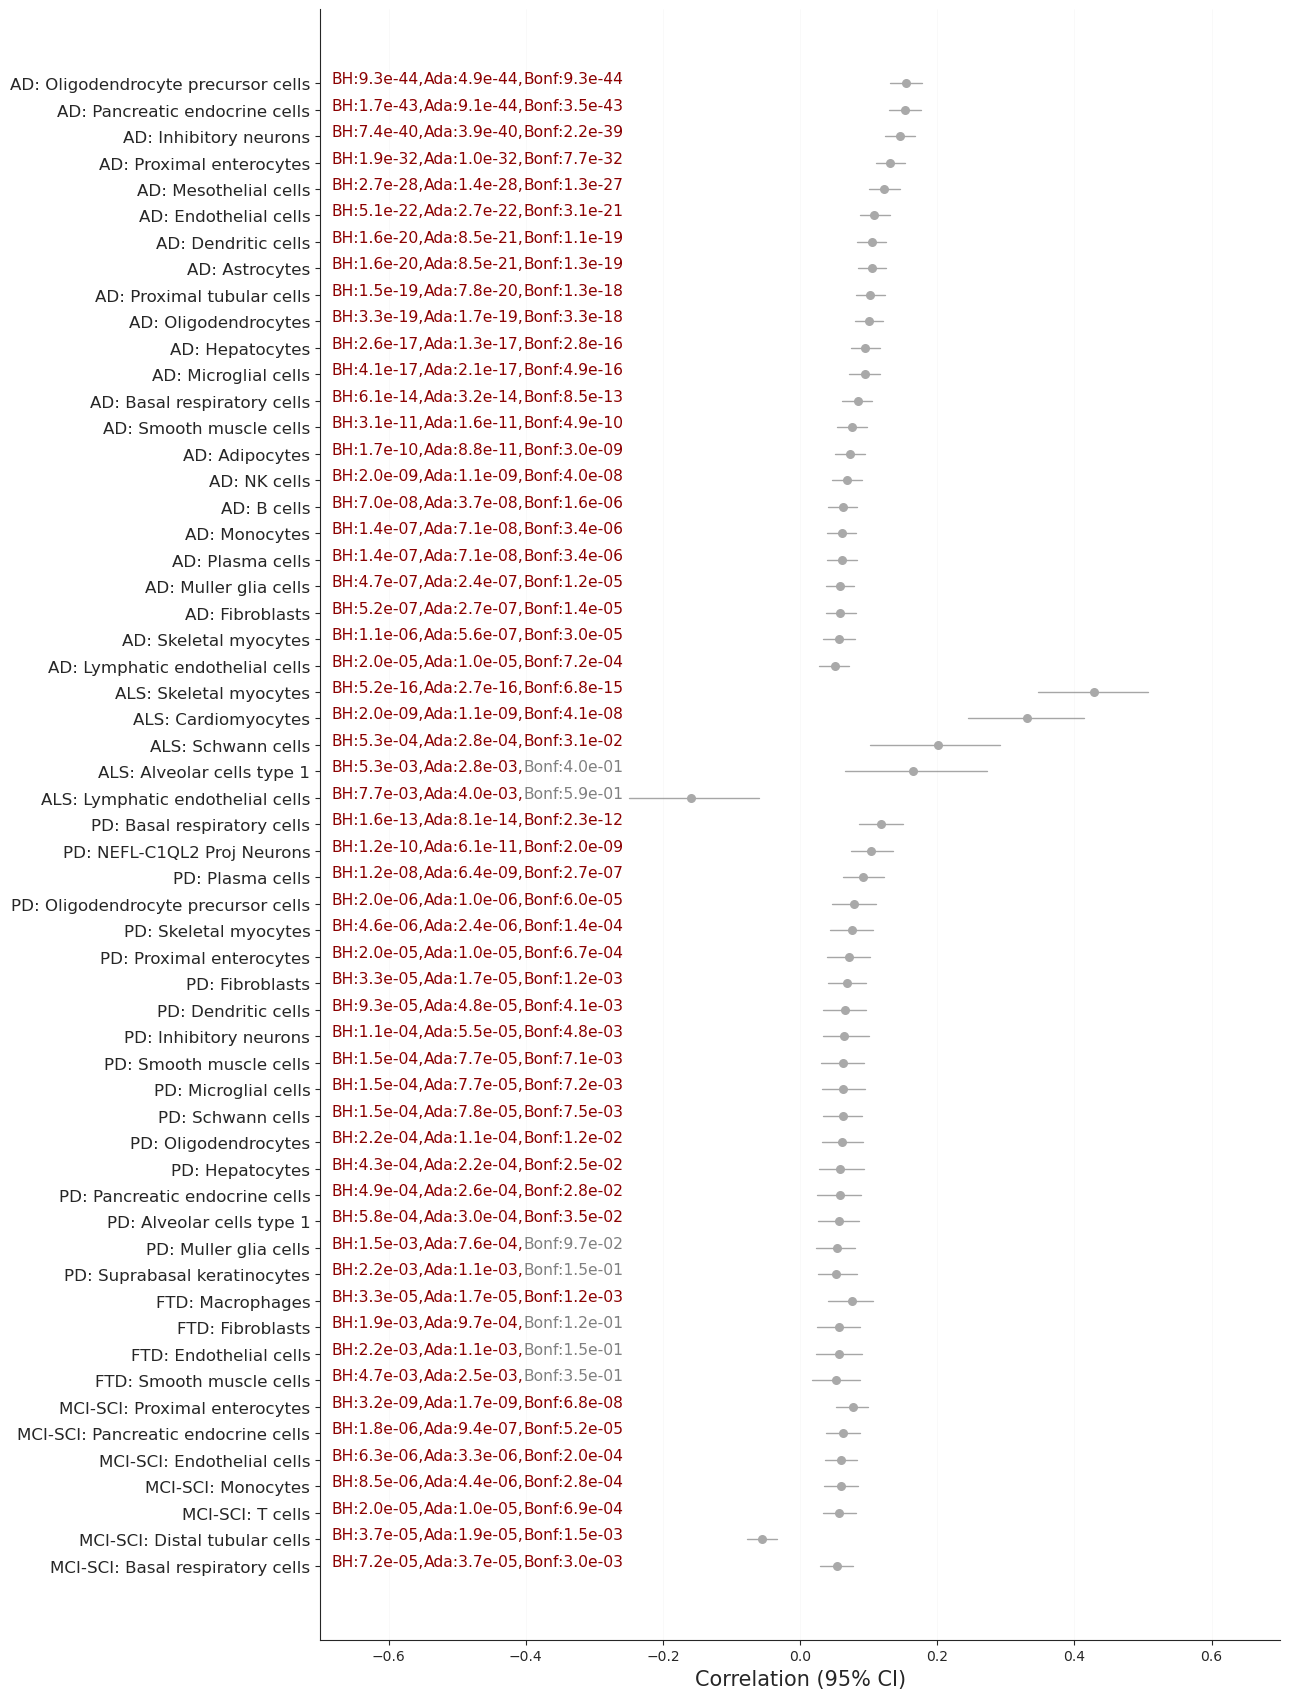

In [39]:
# Sort by outcome order (AD, ALS, PD, FTD, MCI-SCI) and correlation strength
outcome_order = {'AD': 0, 'ALS': 1, 'PD': 2, 'FTD': 3, 'MCI-SCI': 4}
significant_results.sort(key=lambda x: (-outcome_order[x['outcome']], abs(x['correlation'])))

fig, ax = plt.subplots(figsize=(15, len(significant_results) * 0.3))

for i, result in enumerate(significant_results):
    # Plot CI and point in gray
    ax.plot([result['ci_lower'], result['ci_upper']], [i, i], color='gray', linewidth=1, alpha=0.7)
    ax.scatter(result['correlation'], i, color='darkgray', s=30, zorder=2)
    
    # Color-coded p-values based on significance
    bh_color = 'darkred' if result['p_bh'] < 0.05 else 'gray'
    adap_color = 'darkred' if result['p_tsbh'] < 0.05 else 'gray'
    bonf_color = 'darkred' if result['p_bonf'] < 0.05 else 'gray'
    
    # Create text with individual colors
    ax.text(0.108, i, f"BH:{result['p_bh']:.1e},", transform=ax.get_yaxis_transform(), 
            fontsize=11.2, ha='right', color=bh_color)
    ax.text(0.212, i, f"Ada:{result['p_tsbh']:.1e},", transform=ax.get_yaxis_transform(), 
            fontsize=11.2, ha='right', color=adap_color)
    ax.text(0.316, i, f"Bonf:{result['p_bonf']:.1e}", transform=ax.get_yaxis_transform(), 
            fontsize=11.2, ha='right', color=bonf_color)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Format
ax.set_yticks(range(len(significant_results)))
ax.set_yticklabels([f"{r['outcome']}: {r['cell_type'].replace('.', ' ')[:1].upper()+r['cell_type'].replace('.',' ')[1:]}" 
                     for r in significant_results], fontsize=12)
ax.set_xlabel('Correlation (95% CI)', fontsize=15)
ax.set_title('', fontsize=14, pad=15)
ax.grid(True, axis='x', alpha=0.15, linestyle='-', linewidth=0.5)
ax.set_xlim(-0.7, 0.7)

plt.tight_layout()
plt.subplots_adjust(left=0.35)
plt.show()